SilhouetteScore

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_excel("../../datasets/iris row.xlsx")

dataset.head(5)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,5.8,2.7,5.1,1.9
3,6.0,2.2,4.0,1.0
4,5.5,2.3,4.0,1.3


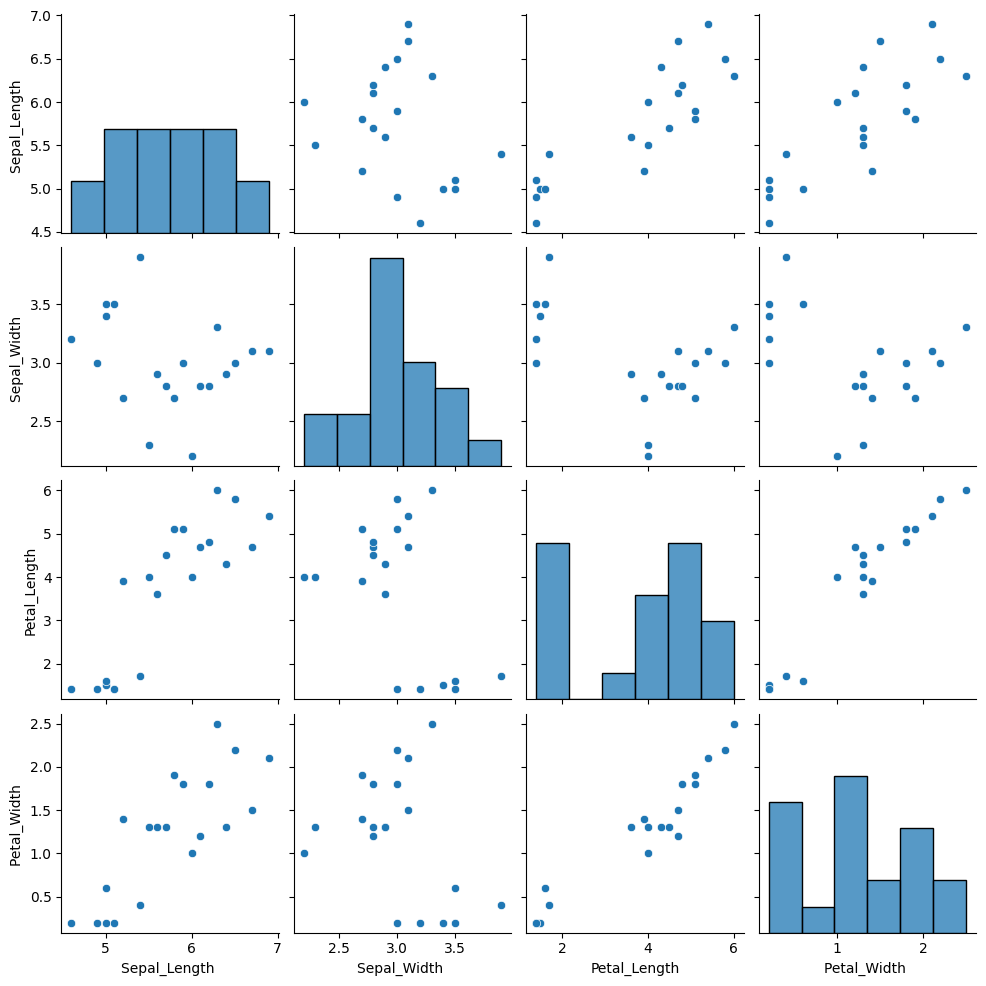

In [18]:
sns.pairplot(data=dataset)
plt.show()

unlabeled data ko split nahi karte

In [19]:
from sklearn.cluster import KMeans

In [20]:
wcss = []

for i in range(2, 21):
    km = KMeans(n_clusters=i, init='k-means++')
    km.fit(dataset)
    wcss.append(km.inertia_)

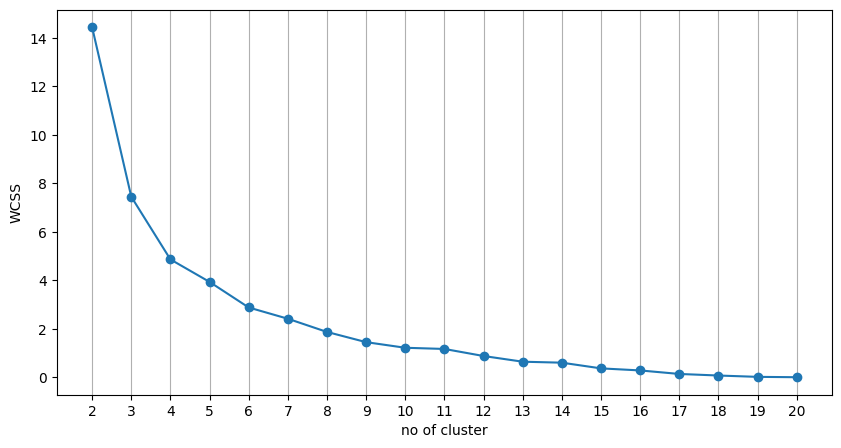

In [21]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2, 21)], wcss, marker="o")
plt.xlabel("no of cluster")
plt.xticks([i for i in range(2, 21)])
plt.ylabel("WCSS")
plt.grid(axis="x")
plt.show()

In [22]:
from sklearn.metrics import silhouette_score

In [23]:
kmn = KMeans(n_clusters=3)
dataset["Predict"] = kmn.fit_predict(dataset)

In [24]:
kmn.labels_

array([1, 1, 0, 2, 2, 0, 2, 0, 1, 2, 1, 2, 0, 1, 2, 2, 0, 1, 0, 0],
      dtype=int32)

In [25]:
silhouette_score(dataset, labels=kmn.labels_)

0.6946593608837358

In [26]:
dataset

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Predict
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,5.8,2.7,5.1,1.9,0
3,6.0,2.2,4.0,1.0,2
4,5.5,2.3,4.0,1.3,2
5,6.3,3.3,6.0,2.5,0
6,5.7,2.8,4.5,1.3,2
7,6.7,3.1,4.7,1.5,0
8,5.0,3.4,1.5,0.2,1
9,6.4,2.9,4.3,1.3,2


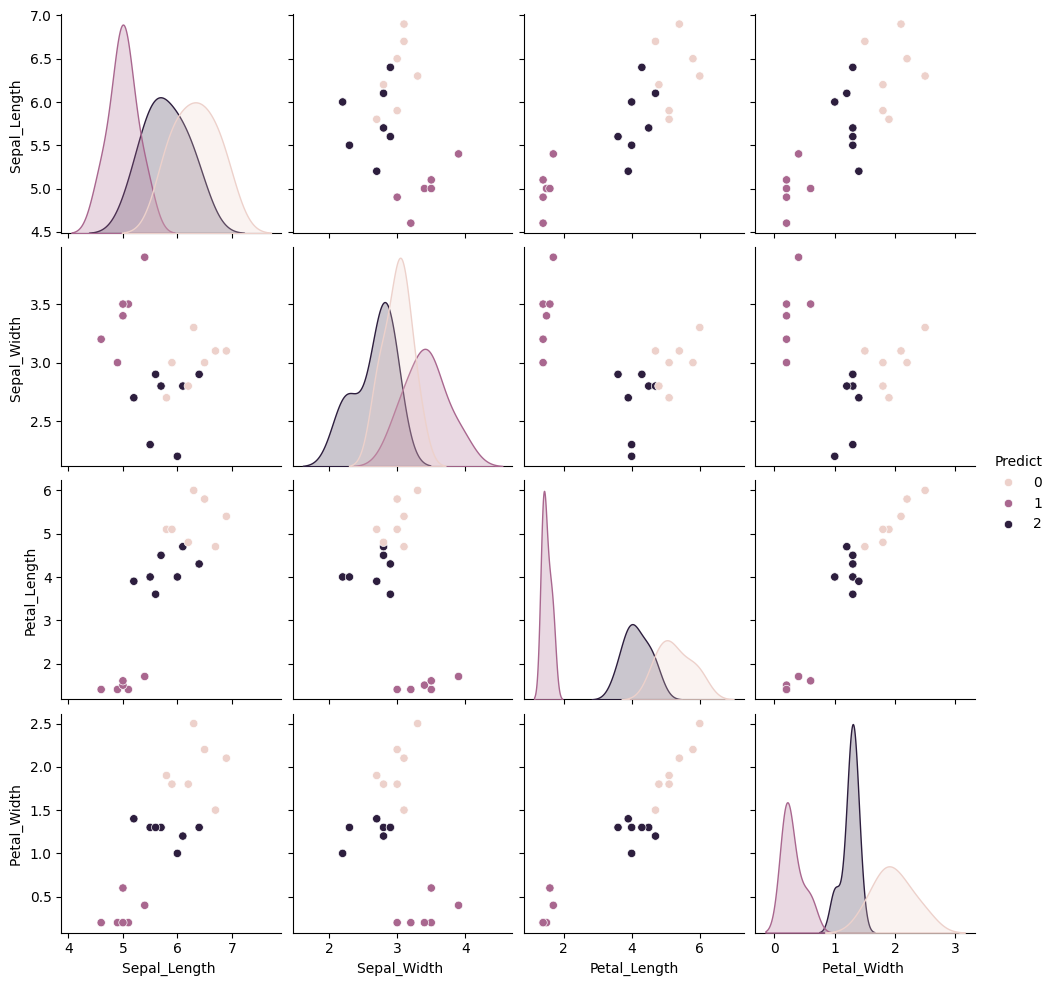

In [27]:
sns.pairplot(data=dataset, hue="Predict")
plt.show()

In [28]:
org_dataset =  pd.read_excel("../../datasets/iris.xlsx")

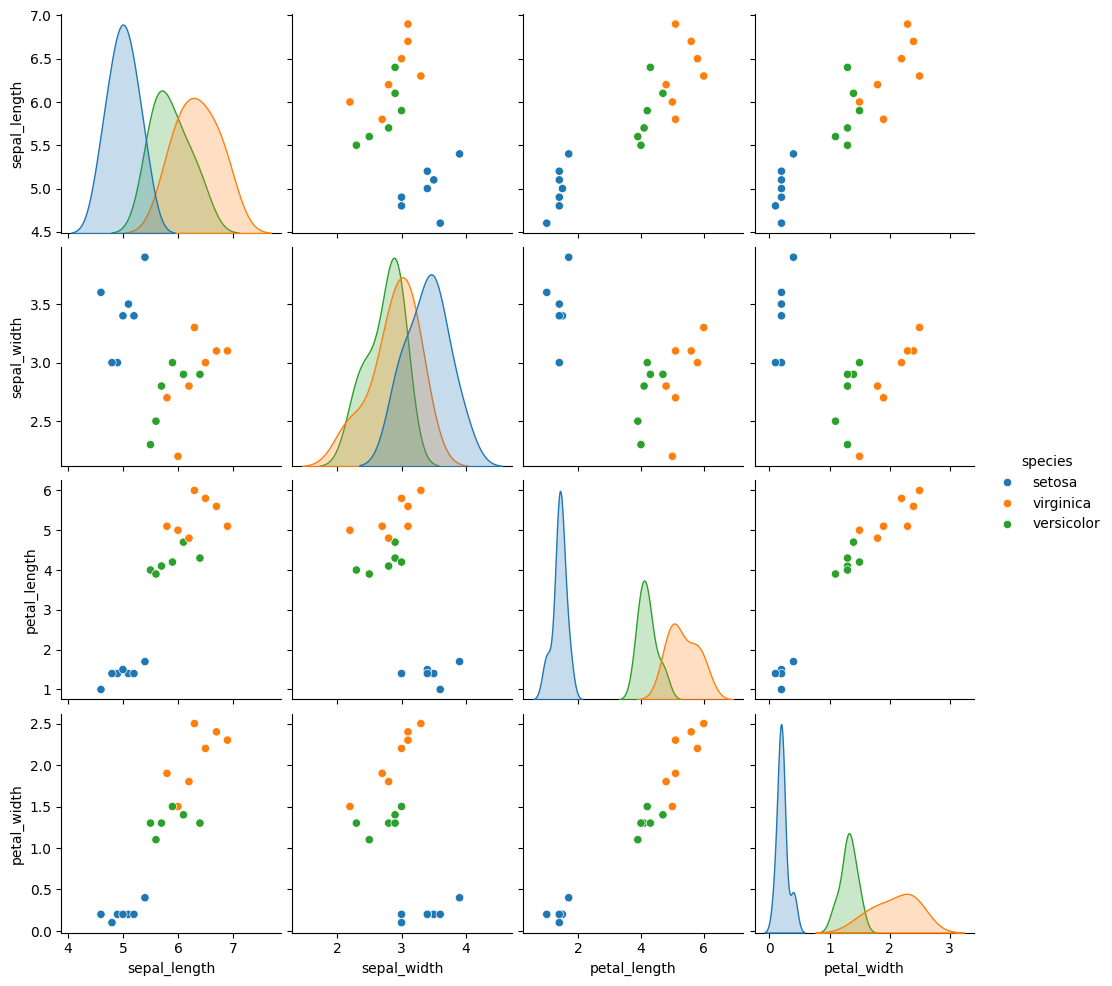

In [29]:
sns.pairplot(data=org_dataset, hue="species")
plt.show()

In [30]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

dataset_scaled = StandardScaler().fit_transform(dataset)

ss = []
no_c = []

for i in range(2, 21):
    try:
        km = KMeans(n_clusters=i, random_state=42, n_init=10)
        labels = km.fit_predict(dataset_scaled)

        score = silhouette_score(dataset_scaled, labels)

        ss.append(score)
        no_c.append(i)

    except:
        print(f"Skipping k={i} due to error")

Skipping k=20 due to error


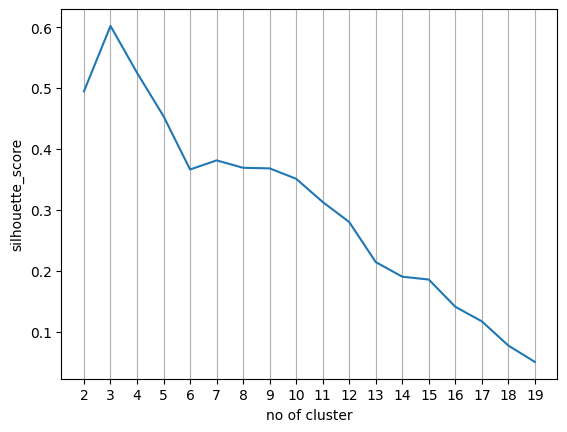

In [32]:
plt.plot(no_c, ss)
plt.xlabel("no of cluster")
plt.ylabel("silhouette_score")
plt.xticks(no_c)
plt.grid(axis="x")
plt.show()